# Assignment 16 - SVM, Trees, Ensembles, Validation & Model Evaluation

## Student Information

**Name:** Suryansh Tiwari

## Dataset Used

For this assignment, I used the **Retail Sales Dataset** created by **Mohammad Talib** from Kaggle.

Dataset Link:
https://www.kaggle.com/datasets/mohammadtalib786/retail-sales-dataset


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('retail_sales_dataset.csv')
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 100.2 KB


In [4]:
df.shape

(1000, 9)

In [5]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [6]:
df.isnull().sum()


Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [8]:
df.duplicated().sum()


np.int64(0)

In [9]:
print("Gender:",df["Gender"].unique())

print("Product Category:", df["Product Category"].unique())

Gender: <ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str
Product Category: <ArrowStringArray>
['Beauty', 'Clothing', 'Electronics']
Length: 3, dtype: str


In [10]:
df["Date"]=pd.to_datetime(df["Date"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[us](1), int64(5), str(3)
memory usage: 90.4 KB


## Initial Observations
Some observations from the exploration:

- The dataset contains **1000 retail transactions** with **9 columns**.
- There are **5 numerical columns**, **3 categorical columns**, and **1 date column**.
- I did not find any missing values or duplicate records, so no cleaning was required at this stage.
- The `Date` column was initially stored as text, so I converted it to datetime format for easier analysis later.
- The `Gender` column has two categories (Male and Female), while the `Product Category` column contains three categories: Beauty, Clothing, and Electronics.
- Looking at the summary statistics, I noticed that the average `Total Amount` (456) is much higher than the median (135). This suggests that there are some high-value transactions that increase the average.

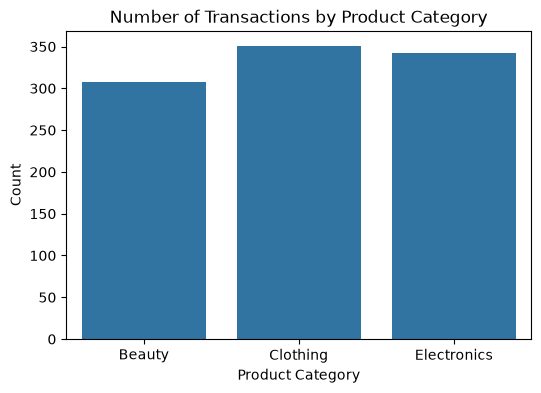

In [11]:
# checking how many transactions belong to each product category

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Product Category")
plt.title("Number of Transactions by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Count")
plt.show()

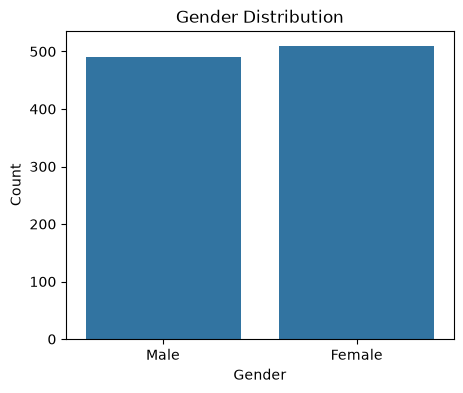

In [12]:
# checking the distribution of male and female customers

plt.figure(figsize=(5,4))
sns.countplot(data=df, x="Gender")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

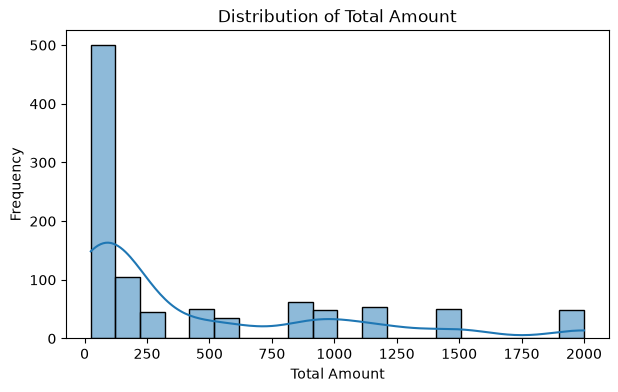

In [13]:
# looking at how total purchase amounts are distributed

plt.figure(figsize=(7,4))
sns.histplot(df["Total Amount"], bins=20, kde=True)
plt.title("Distribution of Total Amount")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")
plt.show()

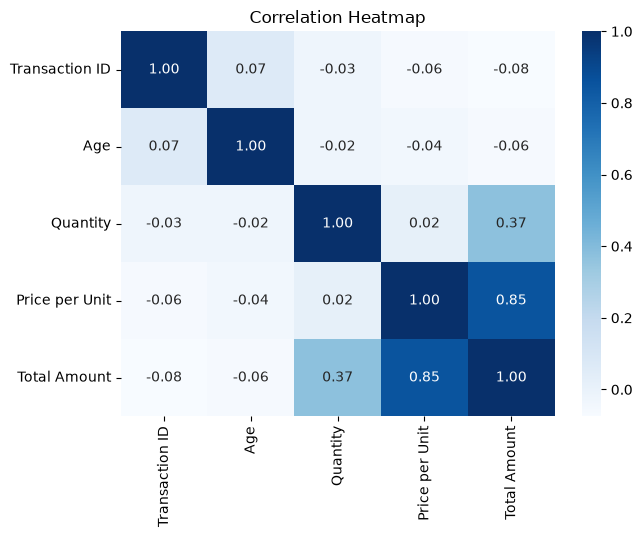

In [14]:
# checking correlation between numerical columns

plt.figure(figsize=(7,5))
corr = df.select_dtypes(include=["int64", "float64"]).corr()
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

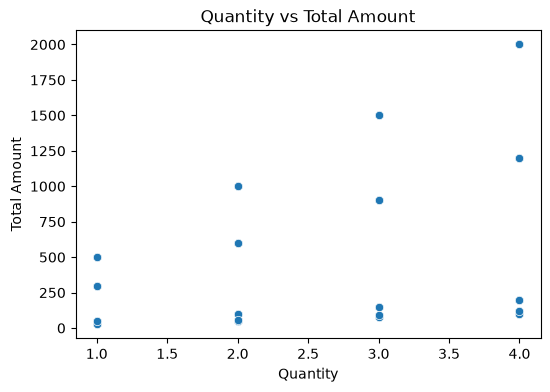

In [15]:
# checking the relationship between quantity and total amount

plt.figure(figsize=(6,4))
sns.scatterplot(data=df,x="Quantity",y="Total Amount")
plt.title("Quantity vs Total Amount")
plt.show()

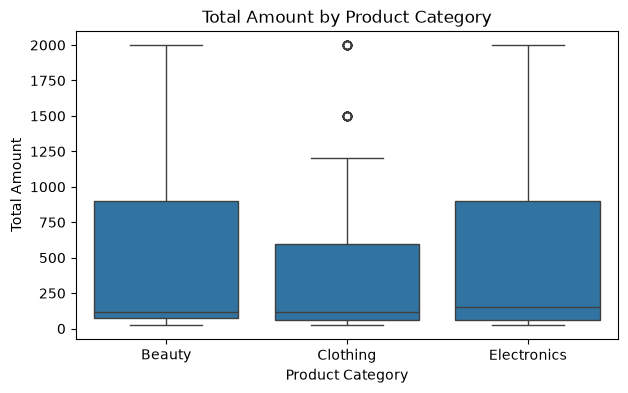

In [16]:
# comparing total amount across product categories

plt.figure(figsize=(7,4))
sns.boxplot(data=df,x="Product Category",y="Total Amount")
plt.title("Total Amount by Product Category")
plt.show()

## Observations from Exploratory Data Analysis

After visualizing the data, I noticed the following:

- The dataset is fairly balanced in terms of gender. There are slightly more female customers than male customers, but the difference is very small.
- Clothing has the highest number of transactions, followed closely by Electronics. Beauty has the fewest transactions, although all three categories are reasonably balanced.
- The distribution of **Total Amount** is right-skewed. Most transactions are of relatively low value, while a few high-value purchases increase the overall average.
- The correlation heatmap shows that **Price per Unit** has a strong positive correlation with **Total Amount** (around 0.85), while **Quantity** has a moderate positive correlation (around 0.37). This makes sense because the total purchase amount depends on both price and quantity.
- The scatter plot also shows that higher quantities generally result in higher total amounts, although the price of the product also affects the final purchase value.
- From the box plot, I observed that all three product categories have a wide range of purchase amounts. Clothing appears to have a few high-value transactions that are shown as outliers.

In [17]:
df["Product Category"].value_counts()

Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

### Choosing the Target Variable

For the classification tasks in this assignment, I decided to use **Product Category** as the target variable.

Initially, I considered creating a new target based on the transaction amount. However, since the transaction amount is calculated using other features in the dataset, it could make the prediction task unrealistically easy. Using the existing product category creates a more meaningful classification problem and helps evaluate the models more fairly.

In [18]:
# selecting the features and target

X = df.drop(columns=["Transaction ID","Customer ID","Date","Product Category"])
y = df["Product Category"]
print("Features:")
print(X.columns.tolist())
print("\nTarget:")
print(y.name)

Features:
['Gender', 'Age', 'Quantity', 'Price per Unit', 'Total Amount']

Target:
Product Category


In [19]:
X.head()

,Gender,Age,Quantity,Price per Unit,Total Amount
0,Male,34,3,50,150
1,Female,26,2,500,1000
2,Male,50,1,30,30
3,Male,37,1,500,500
4,Male,30,2,50,100


In [21]:
X.dtypes

Gender              str
Age               int64
Quantity          int64
Price per Unit    int64
Total Amount      int64
dtype: object

In [22]:
# separating numerical and categorical columns

categorical_features = ["Gender"]
numerical_features = ["Age","Quantity","Price per Unit","Total Amount"]
print("Categorical Features:", categorical_features)
print("Numerical Features:", numerical_features)

Categorical Features: ['Gender']
Numerical Features: ['Age', 'Quantity', 'Price per Unit', 'Total Amount']


In [23]:
# importing libraries required for preprocessing and model building

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 800
Testing samples : 200


In [25]:
# creating a validation set from the training data

X_train_final, X_val, y_train_final, y_val = train_test_split(X_train,y_train,test_size=0.2,random_state=42,stratify=y_train)
print("Training set :", X_train_final.shape[0])
print("Validation set:", X_val.shape[0])
print("Testing set :", X_test.shape[0])

Training set : 640
Validation set: 160
Testing set : 200


### Train, Validation and Test Split

Instead of directly training the model on the entire training set, I created a separate validation set. The validation set will help me compare different model configurations before evaluating the final model on the unseen test set.This approach helps reduce overfitting during model selection.

In [26]:
preprocessor = ColumnTransformer(transformers=[("num", StandardScaler(), numerical_features),("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)])
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## Task-1 : SVM

Firstly we will proceed without any feature scaling, after that i will apply standardization and compare the results

In [27]:
X_train_no_scale = X_train_final.copy()
X_val_no_scale = X_val.copy()
X_test_no_scale = X_test.copy()

X_train_no_scale = pd.get_dummies(X_train_no_scale, columns=["Gender"])
X_val_no_scale = pd.get_dummies(X_val_no_scale, columns=["Gender"])
X_test_no_scale = pd.get_dummies(X_test_no_scale, columns=["Gender"])

X_train_no_scale, X_val_no_scale = X_train_no_scale.align(X_val_no_scale,join="left",axis=1,fill_value=0)
X_train_no_scale, X_test_no_scale = X_train_no_scale.align(X_test_no_scale,join="left",axis=1,fill_value=0)

In [28]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [29]:
# training an SVM without scaling

svm_without_scaling = SVC(kernel="rbf", random_state=42)
svm_without_scaling.fit(X_train_no_scale,y_train_final)
val_predictions = svm_without_scaling.predict(X_val_no_scale)
validation_accuracy = accuracy_score(y_val,val_predictions)
print(f"Validation Accuracy (Without Scaling): {validation_accuracy:.3f}")

Validation Accuracy (Without Scaling): 0.325


### Why try SVM without scaling?

I first trained an SVM without scaling the numerical features to see how much feature scaling affects its performance.

The validation accuracy was quite low (0.325), which suggests that the model struggled because the numerical features are on very different scales. Since SVM relies on distance calculations, scaling the features is generally considered an important preprocessing step.

In [31]:
# applying the preprocessing pipeline

X_train_processed = preprocessor.fit_transform(X_train_final)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

In [32]:
print("Training shape :", X_train_processed.shape)
print("Validation shape:", X_val_processed.shape)
print("Testing shape :", X_test_processed.shape)

Training shape : (640, 6)
Validation shape: (160, 6)
Testing shape : (200, 6)


In [33]:
# training SVM after scaling the numerical features

svm_scaled = SVC(kernel="rbf",random_state=42)
svm_scaled.fit(X_train_processed,y_train_final)
scaled_predictions = svm_scaled.predict(X_val_processed)
scaled_accuracy = accuracy_score(y_val,scaled_predictions)
print(f"Validation Accuracy (With Scaling): {scaled_accuracy:.3f}")

Validation Accuracy (With Scaling): 0.319


In [34]:
print("Without Scaling:", validation_accuracy)
print("With Scaling:", scaled_accuracy)

Without Scaling: 0.325
With Scaling: 0.31875


In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

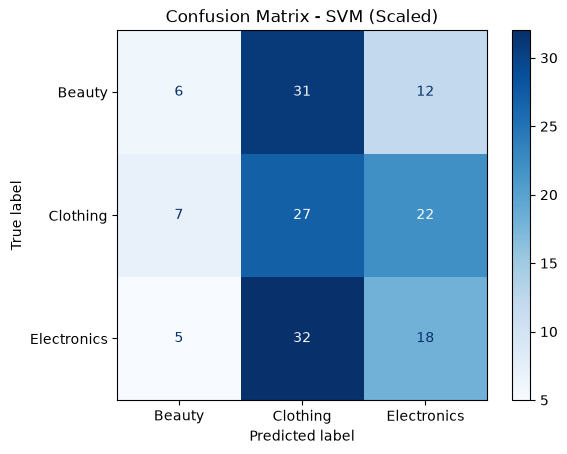

In [36]:
cm = confusion_matrix(y_val, scaled_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=svm_scaled.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - SVM (Scaled)")
plt.show()

In [37]:
from sklearn.metrics import classification_report
print(classification_report(y_val, scaled_predictions))

              precision    recall  f1-score   support

      Beauty       0.33      0.12      0.18        49
    Clothing       0.30      0.48      0.37        56
 Electronics       0.35      0.33      0.34        55

    accuracy                           0.32       160
   macro avg       0.33      0.31      0.30       160
weighted avg       0.33      0.32      0.30       160



### Observation

The confusion matrix shows that the SVM classifier tends to predict **Clothing** more frequently than the other categories. Many Beauty and Electronics transactions are incorrectly classified as Clothing.

This suggests that the selected features (Age, Gender, Quantity, Price per Unit and Total Amount) are not sufficient to clearly separate the three product categories. The overlap between these features makes the classification task difficult, which explains the relatively low validation accuracy.

In [39]:
# training SVM with a linear kernel

svm_linear = SVC(kernel="linear",random_state=42)
svm_linear.fit(X_train_processed, y_train_final)
linear_predictions = svm_linear.predict(X_val_processed)
linear_accuracy = accuracy_score(y_val, linear_predictions)
print(f"Validation Accuracy (Linear Kernel): {linear_accuracy:.3f}")

Validation Accuracy (Linear Kernel): 0.306


In [41]:
print(f"Linear Kernel: {linear_accuracy:.3f}")
print(f"RBF Kernel: {scaled_accuracy:.3f}")

Linear Kernel: 0.306
RBF Kernel: 0.319


### Comparing Linear and RBF Kernels

I trained two SVM models using different kernels.

Linear - 0.306 |
RBF - 0.319 

The RBF kernel performed slightly better than the Linear kernel, but the improvement was very small. This suggests that the relationship between the selected features and the target variable is not easily separable, even with a non-linear kernel.

The relatively low accuracy indicates that the available features do not provide enough information to clearly distinguish between the three product categories.

In [42]:
# trying different values of C using the validation set

C_values = [0.01, 0.1, 1, 10, 100]
results = []
for c in C_values:
    model = SVC(kernel="rbf",C=c,random_state=42)
    model.fit(X_train_processed, y_train_final)
    predictions = model.predict(X_val_processed)
    accuracy = accuracy_score(y_val, predictions)
    results.append({"C": c,"Validation Accuracy": accuracy})
results_df = pd.DataFrame(results)
results_df

,C,Validation Accuracy
0,0.01,0.35000
1,0.10,0.36250
2,1.00,0.31875
3,10.00,0.27500
4,100.00,0.35625


In [43]:
best_row = results_df.loc[results_df["Validation Accuracy"].idxmax()]
best_row

C                      0.1000
Validation Accuracy    0.3625
Name: 1, dtype: float64

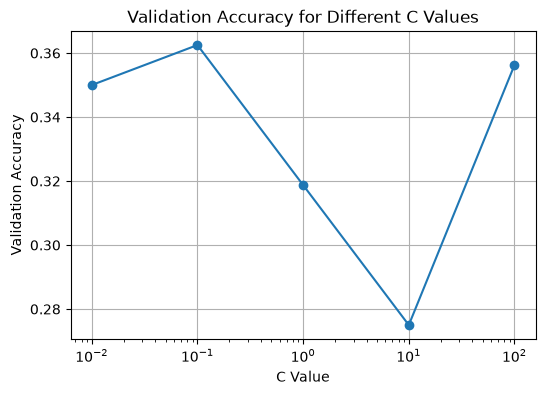

In [44]:
plt.figure(figsize=(6,4))
plt.plot(results_df["C"],results_df["Validation Accuracy"],marker="o")
plt.xscale("log")
plt.xlabel("C Value")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy for Different C Values")
plt.grid(True)
plt.show()

### Parameter Tuning

Instead of using the default SVM parameters, I experimented with different values of the regularization parameter **C**.

I observed that the model performed best when **C = 0.1**. Increasing the value of C did not improve the validation accuracy. In fact, larger values reduced the model's performance.

Based on these observations, I selected **C = 0.1** as the final parameter for the SVM model.

In [45]:
# training the final SVM model using the best value of C

final_svm = SVC(kernel="rbf",C=0.1,random_state=42)
final_svm.fit(X_train_processed, y_train_final)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [46]:
# evaluating on the validation set

val_predictions = final_svm.predict(X_val_processed)
val_accuracy = accuracy_score(y_val, val_predictions)
print(f"Validation Accuracy: {val_accuracy:.3f}")

Validation Accuracy: 0.362


In [47]:
# evaluating on the unseen test set

test_predictions = final_svm.predict(X_test_processed)
test_accuracy = accuracy_score(y_test,test_predictions)
print(f"Test Accuracy: {test_accuracy:.3f}")

Test Accuracy: 0.345


In [48]:
print(classification_report(y_test,test_predictions))

              precision    recall  f1-score   support

      Beauty       0.00      0.00      0.00        62
    Clothing       0.35      0.99      0.51        70
 Electronics       0.00      0.00      0.00        68

    accuracy                           0.34       200
   macro avg       0.12      0.33      0.17       200
weighted avg       0.12      0.34      0.18       200



e:\GenAI\python\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\GenAI\python\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\GenAI\python\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


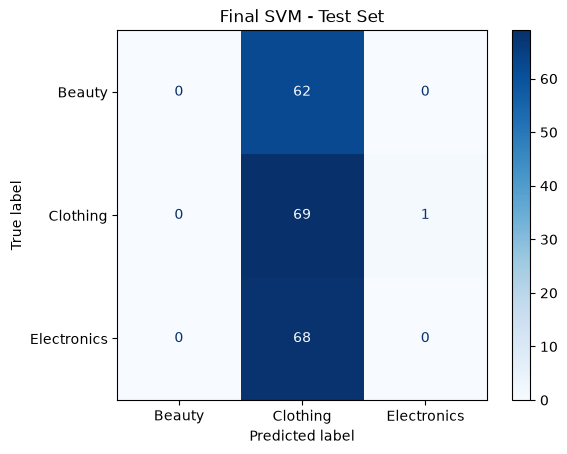

In [49]:
cm = confusion_matrix(y_test,test_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=final_svm.classes_)
disp.plot(cmap="Blues")
plt.title("Final SVM - Test Set")
plt.show()

In [50]:
comparison = pd.DataFrame({
    "Model": ["SVM (RBF, No Scaling)","SVM (RBF, Scaled)","SVM (Linear)","SVM (Best C = 0.1)"],
    "Validation Accuracy": [validation_accuracy,scaled_accuracy,linear_accuracy,val_accuracy]})
comparison

,Model,Validation Accuracy
0,"SVM (RBF, No Scaling)",0.32500
1,"SVM (RBF, Scaled)",0.31875
2,SVM (Linear),0.30625
3,SVM (Best C = 0.1),0.36250


### Final Observation

I experimented with different SVM configurations instead of using a single model.

Some key observations from this process were:

- Scaling the numerical features did not significantly improve the validation accuracy for this dataset.
- The RBF kernel performed slightly better than the Linear kernel.
- Testing multiple values of the regularization parameter (C) showed that **C = 0.1** gave the best validation accuracy.
- Even after tuning, the model struggled to separate the three product categories.

When I evaluated the final model on the test set, I noticed that the classifier predicted **Clothing** for most transactions. This suggests that the available features (Age, Gender, Quantity, Price per Unit and Total Amount) do not contain enough information to clearly distinguish between the three product categories.

This experiment reminded me that choosing a powerful algorithm alone does not guarantee good performance. Feature quality and the relationship between the features and the target variable are equally important.

## Task-2 : Decission Tree Classifier

In [51]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

In [52]:
small_tree = DecisionTreeClassifier(max_depth=2,random_state=42)
small_tree.fit(X_train_processed, y_train_final)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

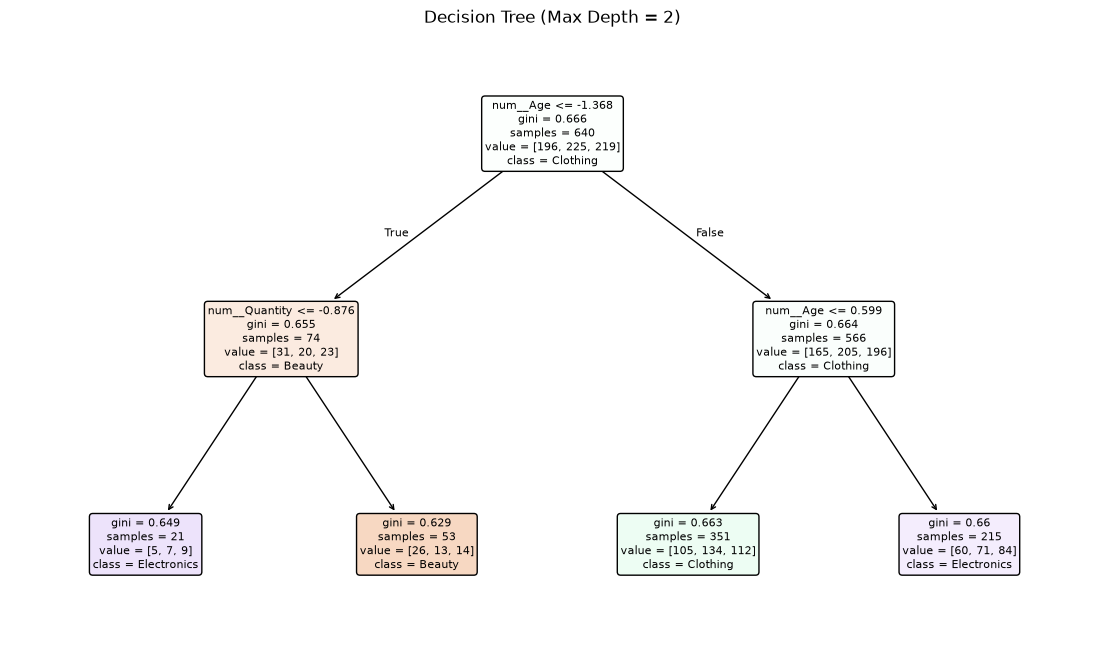

In [53]:
plt.figure(figsize=(14,8))
plot_tree(small_tree,feature_names=preprocessor.get_feature_names_out(),class_names=small_tree.classes_,filled=True,rounded=True,fontsize=8)
plt.title("Decision Tree (Max Depth = 2)")
plt.show()

In [54]:
small_train_pred = small_tree.predict(X_train_processed)
small_test_pred = small_tree.predict(X_test_processed)
small_train_acc = accuracy_score(y_train_final,small_train_pred)
small_test_acc = accuracy_score(y_test,small_test_pred)
print("Training Accuracy :", round(small_train_acc,3))
print("Testing Accuracy  :", round(small_test_acc,3))

Training Accuracy : 0.395
Testing Accuracy  : 0.33


In [55]:
large_tree = DecisionTreeClassifier(max_depth=10,random_state=42)
large_tree.fit(X_train_processed,y_train_final)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at

In [56]:
large_train_pred = large_tree.predict(X_train_processed)
large_test_pred = large_tree.predict(X_test_processed)
large_train_acc = accuracy_score(y_train_final,large_train_pred)
large_test_acc = accuracy_score(y_test,large_test_pred)
print("Training Accuracy :", round(large_train_acc,3))
print("Testing Accuracy  :", round(large_test_acc,3))

Training Accuracy : 0.695
Testing Accuracy  : 0.315


In [57]:
tree_results = pd.DataFrame({
    "Model":[
        "Decision Tree (Depth = 2)",
        "Decision Tree (Depth = 10)"
    ],
    "Training Accuracy":[
        small_train_acc,
        large_train_acc
    ],
    "Testing Accuracy":[
        small_test_acc,
        large_test_acc
    ]
})
tree_results

,Model,Training Accuracy,Testing Accuracy
0,Decision Tree (Depth = 2),0.395313,0.330
1,Decision Tree (Depth = 10),0.695312,0.315


### My Observation

The shallow Decision Tree (max_depth = 2) achieved similar training and testing accuracies, but both were quite low. This suggests that the model was too simple and could not learn enough patterns from the dataset.

When I increased the tree depth to 10, the training accuracy improved from about 40% to nearly 70%. However, the testing accuracy slightly decreased instead of improving.

From this experiment, I understood that increasing the complexity of a Decision Tree does not always improve its performance on unseen data. A deeper tree can start fitting the training data too closely, reducing its ability to generalize. Although the difference is not very large here, it shows the beginning of overfitting.

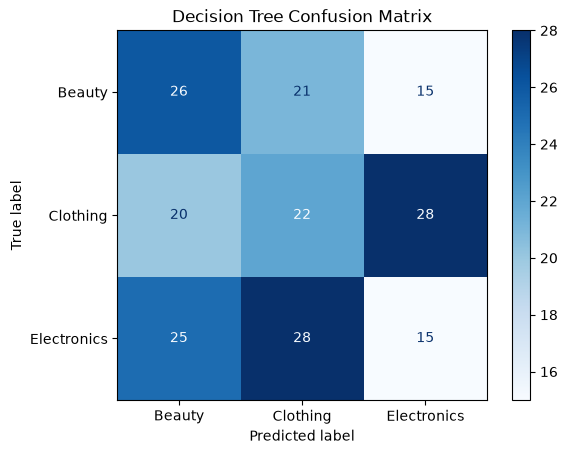

In [58]:
cm = confusion_matrix(y_test,large_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=large_tree.classes_)
disp.plot(cmap="Blues")
plt.title("Decision Tree Confusion Matrix")
plt.show()

### Confusion Matrix Analysis

The confusion matrix shows that the Decision Tree predicts all three product categories, but many samples are still classified incorrectly.

The model often confuses Beauty, Clothing, and Electronics, indicating that the current features are not strong enough to clearly distinguish between the categories.

This also explains why the testing accuracy remains relatively low even after increasing the tree depth.

# Part 2 – Model Validation & Cross Validation

## Task 3 – Train, Validation and Test Split

For the SVM model, I divided the dataset into three parts:

- Training Set (used to train the model)
- Validation Set (used to compare different values of C)
- Test Set (used only for final evaluation)

This allowed me to tune the model without using the test data, helping to avoid data leakage.

In [59]:
print("Training Samples   :", len(X_train_final))
print("Validation Samples :", len(X_val))
print("Testing Samples    :", len(X_test))

Training Samples   : 640
Validation Samples : 160
Testing Samples    : 200


In [61]:
split_df = pd.DataFrame({
    "Dataset": ["Training", "Validation", "Testing"],
    "Samples": [len(X_train_final),len(X_val),len(X_test)]
})

split_df

,Dataset,Samples
0,Training,640
1,Validation,160
2,Testing,200


### My Observation

Using separate training, validation and testing datasets helped me evaluate the model more fairly.

The validation set was used only for selecting the best value of C, while the test set remained completely unseen until the final evaluation. This gives a more reliable estimate of how the model performs on new data.

## Task-4 : Cross - Validation

In [62]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

In [63]:
kfold = KFold(n_splits=5,shuffle=True,random_state=42)

In [64]:
from sklearn.pipeline import Pipeline
svm_pipeline = Pipeline([("preprocessor", preprocessor),("classifier", SVC(kernel="rbf", C=0.1))])

In [65]:
cv_scores = cross_val_score(svm_pipeline,X,y,cv=kfold,scoring="accuracy")
print("Cross Validation Scores:")
print(cv_scores)

Cross Validation Scores:
[0.3   0.355 0.335 0.31  0.34 ]


In [66]:
print("Average Accuracy :", round(cv_scores.mean(),3))
print("Standard Deviation :", round(cv_scores.std(),3))

Average Accuracy : 0.328
Standard Deviation : 0.02


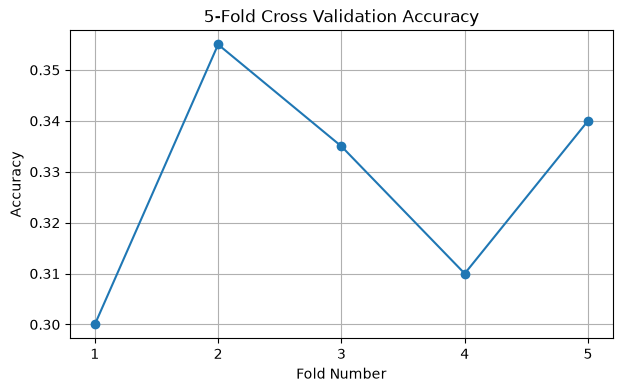

In [67]:
plt.figure(figsize=(7,4))
plt.plot(range(1,6),cv_scores,marker="o")
plt.xticks(range(1,6))
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross Validation Accuracy")
plt.grid(True)
plt.show()

In [69]:
comparison = pd.DataFrame({
    "Evaluation Method": [
        "Validation Set",
        "5-Fold Cross Validation"
    ],
    "Accuracy": [
        0.3625,
        cv_scores.mean()
    ]
})

comparison

,Evaluation Method,Accuracy
0,Validation Set,0.3625
1,5-Fold Cross Validation,0.3280


### My Observation

The cross-validation accuracies ranged from **30% to 35.5%**, with an average accuracy of about **32.8%**.

The standard deviation is quite small (around **0.02**), which means the model performs consistently across different folds. This suggests that the performance is stable and not heavily dependent on a particular train-test split.

Comparing these results with the validation accuracy, I noticed that they are fairly close. This gives me more confidence that the model's performance is realistic.

Overall, I think the low accuracy is mainly due to the limited predictive power of the available features rather than an issue with the validation process.

## Part-3 : Ensemble Learning

## Task-5 : Bagging vs Boosting

In [70]:
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier

In [71]:
bagging_model = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),n_estimators=50,random_state=42)
bagging_model.fit(X_train_processed,y_train_final)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...ndom_state=42)
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",50
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary <warm_start>`... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [72]:
bagging_train_pred = bagging_model.predict(X_train_processed)
bagging_test_pred = bagging_model.predict(X_test_processed)
bagging_train_acc = accuracy_score(y_train_final,bagging_train_pred)
bagging_test_acc = accuracy_score(y_test,bagging_test_pred)
print("Training Accuracy :", round(bagging_train_acc,3))
print("Testing Accuracy  :", round(bagging_test_acc,3))

Training Accuracy : 0.886
Testing Accuracy  : 0.29


In [73]:
adaboost_model = AdaBoostClassifier(n_estimators=50,random_state=42)
adaboost_model.fit(X_train_processed,y_train_final)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[object](3,)","['Beauty','Clothing','Electronics']"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeClassifier,DecisionTreeC...r(max_depth=1)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](50,)","[0.63,0.63,0.65,...,0.66,0.65,0.66]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](50,)","[0.16,0.15,0.08,...,0.05,0.07,0.04]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[DecisionTreeC...te=1608637542), DecisionTreeC...te=1273642419), DecisionTreeC...te=1935803228), DecisionTreeC...ate=787846414), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](6,)","[0.48,0.02,0.02,0.44,0.03,0. ]"


In [74]:
adaboost_train_pred = adaboost_model.predict(X_train_processed)
adaboost_test_pred = adaboost_model.predict(X_test_processed)
adaboost_train_acc = accuracy_score(y_train_final,adaboost_train_pred)
adaboost_test_acc = accuracy_score(y_test,adaboost_test_pred)
print("Training Accuracy :", round(adaboost_train_acc,3))
print("Testing Accuracy  :", round(adaboost_test_acc,3))

Training Accuracy : 0.423
Testing Accuracy  : 0.335


In [75]:
ensemble_results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Bagging",
        "AdaBoost"
    ],
    "Training Accuracy": [
        large_train_acc,
        bagging_train_acc,
        adaboost_train_acc
    ],
    "Testing Accuracy": [
        large_test_acc,
        bagging_test_acc,
        adaboost_test_acc
    ]
})

ensemble_results

,Model,Training Accuracy,Testing Accuracy
0,Decision Tree,0.695312,0.315
1,Bagging,0.885938,0.290
2,AdaBoost,0.423438,0.335


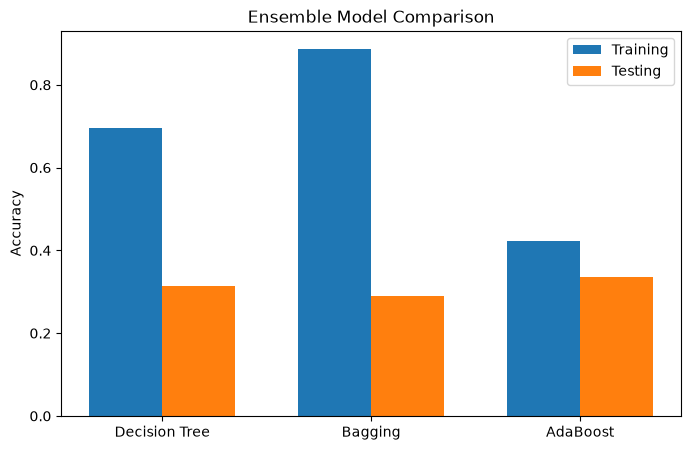

In [ ]:
plt.figure(figsize=(8,5))

x = np.arange(len(ensemble_results))
width = 0.35

plt.bar(
    x - width/2,
    ensemble_results["Training Accuracy"],
    width,
    label="Training"
)

plt.bar(
    x + width/2,
    ensemble_results["Testing Accuracy"],
    width,
    label="Testing"
)

plt.xticks(x,ensemble_results["Model"])
plt.ylabel("Accuracy")
plt.title("Ensemble Model Comparison")
plt.legend()
plt.show()

### My Observation

The three models behaved quite differently on this dataset.

The Bagging classifier achieved the highest training accuracy (around 89%), but its testing accuracy dropped to about 29%. This suggests that the model learned the training data very well but did not generalize effectively to unseen data.

AdaBoost showed the opposite behavior. Its training accuracy was much lower (around 42%), but it achieved the highest testing accuracy (33.5%) among the three models. Although the improvement is small, it indicates that AdaBoost generalized slightly better than the other models.

From this comparison, I learned that a higher training accuracy does not always mean a better model. The ability to perform well on unseen data is more important than simply fitting the training data.

## Task-6 : Random Forest (Bagging)

In [78]:
from sklearn.ensemble import RandomForestClassifier

In [79]:
random_forest = RandomForestClassifier(n_estimators=100,random_state=42)
random_forest.fit(X_train_processed,y_train_final)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [80]:
rf_train_pred = random_forest.predict(X_train_processed)
rf_test_pred = random_forest.predict(X_test_processed)

In [81]:
rf_train_acc = accuracy_score(y_train_final,rf_train_pred)
rf_test_acc = accuracy_score(y_test,rf_test_pred)
print("Training Accuracy :", round(rf_train_acc,3))
print("Testing Accuracy  :", round(rf_test_acc,3))

Training Accuracy : 0.887
Testing Accuracy  : 0.32


In [82]:
print("Random Forest Classification Report\n")
print(classification_report(y_test,rf_test_pred))

Random Forest Classification Report

              precision    recall  f1-score   support

      Beauty       0.30      0.27      0.29        62
    Clothing       0.32      0.33      0.32        70
 Electronics       0.34      0.35      0.35        68

    accuracy                           0.32       200
   macro avg       0.32      0.32      0.32       200
weighted avg       0.32      0.32      0.32       200



In [83]:
comparison_df = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Bagging",
        "Random Forest"
    ],
    "Training Accuracy": [
        large_train_acc,
        bagging_train_acc,
        rf_train_acc
    ],
    "Testing Accuracy": [
        large_test_acc,
        bagging_test_acc,
        rf_test_acc
    ]
})

comparison_df


,Model,Training Accuracy,Testing Accuracy
0,Decision Tree,0.695312,0.315
1,Bagging,0.885938,0.290
2,Random Forest,0.887500,0.320


In [84]:
feature_importance = pd.DataFrame({
    "Feature": preprocessor.get_feature_names_out(),
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,num__Age,0.709146
3,num__Total Amount,0.123400
2,num__Price per Unit,0.071218
1,num__Quantity,0.062971
4,cat__Gender_Female,0.017027
5,cat__Gender_Male,0.016239


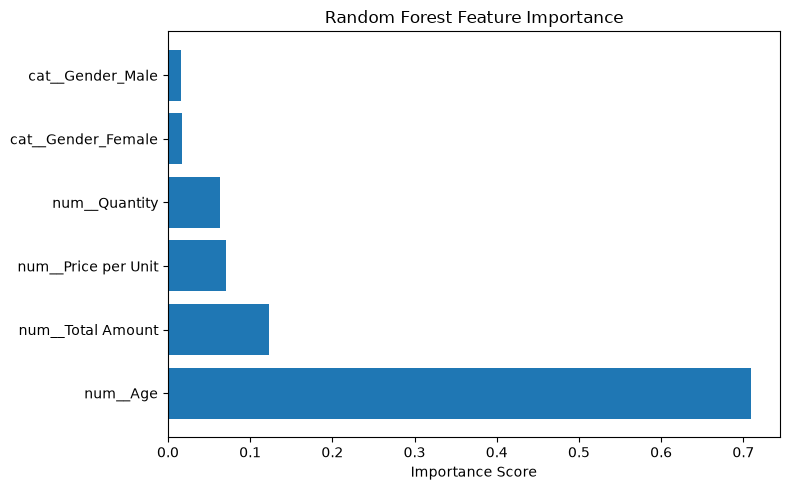

In [85]:
plt.figure(figsize=(8,5))

plt.barh(feature_importance["Feature"],feature_importance["Importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

### Random Forest Analysis

### Observations

- Random Forest achieved a testing accuracy of about 32%, which is slightly higher than the Decision Tree but still fairly low.
- Bagging produced the highest training accuracy, but its testing accuracy dropped, suggesting that it memorized the training data without improving generalization.
- Random Forest reduced overfitting slightly by combining predictions from multiple trees, but the improvement is limited because the dataset itself contains very little information that separates the three product categories.

### Feature Importance

From the feature importance values:

- Age is the most influential feature.
- Total Amount and Price per Unit also contribute to the prediction.
- Gender contributes very little.

This indicates that customer purchasing behaviour in this dataset is influenced more by age and transaction values than by gender.

# My Learning from this Assignment

While working on this assignment I noticed that simply using more advanced algorithms does not always improve model performance.

Initially I expected Random Forest and Bagging to perform much better than a single Decision Tree. However, after comparing the results, I observed that all models achieved only around 30–33% testing accuracy.

This made me inspect the dataset more carefully. The product categories appear to have a lot of overlap in terms of Age, Quantity, Price per Unit and Total Amount. Because of this, even powerful algorithms struggle to separate the classes.

I also learned why feature scaling is important for SVMs and why cross-validation gives a more reliable estimate than relying on a single train-test split.

Overall, this assignment helped me understand that model performance depends not only on the algorithm but also on the quality and characteristics of the dataset.